In [1]:
from pathlib import Path
import sys, os

scriptPath = Path.cwd()
parentPath = scriptPath.parent
dataPath = parentPath / 'data'
srcPath = parentPath / 'src'
modelPath = parentPath / 'models'
savePath = parentPath / 'results'
plotPath = parentPath / 'plots'

sys.path.append(srcPath.as_posix())

In [2]:
import torch
from torchvision import datasets, transforms

test_batch_size = 200
image_size = 28
num_classes = 10

# Dataset
testset = datasets.FashionMNIST(dataPath, train=False, transform=transforms.Compose([
                       transforms.Resize(image_size),
                       transforms.ToTensor()
                   ]))
test_loader = torch.utils.data.DataLoader(testset, batch_size=test_batch_size, shuffle=False)

calibration_factor = 2.15
for i, (data, target) in enumerate(test_loader):
    test_input_i, test_labels_i = data*calibration_factor, target
    if i==0:
        break

In [3]:
def format_pivot(results_df_pivot):
    # Move K→∞ to the last column
    cols = results_df_pivot.columns.tolist()
    if 0 in cols:
        cols = [col for col in cols if col != 0] + [0]
    results_df_pivot = results_df_pivot[cols]

    def print_K(K):
        if K==0:
            return 'K → ∞'
        else:
            return f'K = {K}'

    results_df_pivot.index = [f"N = {nh}" for nh in results_df_pivot.index]
    results_df_pivot.columns = [print_K(k) for k in results_df_pivot.columns]
    
    return results_df_pivot

## Load the trained models

In [4]:
from PANS_linear import PANS_active

device = 'cpu'

exp_models = {}
exp_Ns = []
for f in os.listdir(modelPath):
    if f.startswith(f'fashion_expmodel_N'):
        N = int(f.split('_')[2][1:].split('.')[0])
        exp_Ns.append(N)
        print(N,f)

        n_chans = []
        n_kers = 0
        pool_size = 2      
        fc_config = [512]
        pool_type = 'avg'
        if_logsoft = True

        model = PANS_active(n_input=image_size**2, n_output=num_classes, n_feature=N, pool_type=pool_type, conv_channels=n_chans, conv_kernel=n_kers, pool_size=pool_size, fc_units=fc_config, use_feature_batchnorm=True,use_logsoft=if_logsoft).to(device)

        model.load_state_dict(torch.load(modelPath / f, map_location=device))
        model.to(device)
        model.eval()
        exp_models[N] = model

exp_Ns.sort()
exp_Ns

16 fashion_expmodel_N16.pth
10 fashion_expmodel_N10.pth
3 fashion_expmodel_N3.pth
4 fashion_expmodel_N4.pth
6 fashion_expmodel_N6.pth
32 fashion_expmodel_N32.pth
24 fashion_expmodel_N24.pth


[3, 4, 6, 10, 16, 24, 32]

# Experimental results
## Load the detected photon counts

In [5]:
import numpy as np

exp_actvs = np.load(dataPath/'exp_actv'/'fashion_acts_qcmos.npy',allow_pickle=True).item()
exp_actvs.keys()

dict_keys([10, 32, 3, 4, 6, 8, 16, 24])

## Digital back-end inference

In [6]:
import pandas as pd
import numpy as np
import torch

# create a DataFrame for the results
exp_results_df = pd.DataFrame(columns=['N', 'K', 'mean_accuracy','std_dev','det_photon_count','illum_photon_count'])

Ks = np.r_[1,2,3,5]
acc_arr = np.zeros((len(Ks)))

temp_results = []

for N in exp_Ns:
    for Ki, K in enumerate(Ks):
        # Regroup every K shots of the measured binary values to calculate the activations
        det_actv = torch.from_numpy(exp_actvs[N].reshape(K,-1,test_batch_size,N,order='F').mean(axis=0)).type(torch.float)
        accr = np.zeros((det_actv.shape[1],det_actv.shape[0]))
        for i in range(det_actv.shape[0]):
            results = exp_models[N].acts_out(det_actv[i]).argmax(axis=1)==test_labels_i
            accr[:,i] = results.detach().cpu().numpy()

        mean_acc = (100. * accr.mean())
        std_dev = (100. * accr.mean(axis=0).std())
        illum_pc = ((exp_models[N].input_weights.detach().cpu().numpy())**2).sum()*K
        det_pc = det_actv.mean().item()*N*K

        print(f"{N} detectors x {K} shots: {np.round(mean_acc,2):.2f} ± {np.round(std_dev,2):.2f}%\nPhoton count {det_pc:.5f} Illumination {illum_pc:6g} \n")

        # append the results to DataFrame
        temp_results.append({'N': N, 'K': int(K), 'mean_accuracy': mean_acc, 'std_dev': std_dev, 'det_photon_count': det_pc, 'illum_photon_count': illum_pc})

exp_results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)

# Pivot the DataFrame so that 'K' are columns and 'N' are rows with 'mean_accuracy' and 'std_dev' together in the same cell
exp_results_df['results'] = exp_results_df.apply(lambda row: \
                    f"{np.round(row['mean_accuracy'],2):.2f} ± {np.round(row['std_dev'],2):.2f}%", axis=1)
exp_results_df_print = format_pivot(exp_results_df.pivot(index='N', columns='K', values='results'))

exp_results_df_print

3 detectors x 1 shots: 52.35 ± 1.43%
Photon count 1.28050 Illumination 18.1172 

3 detectors x 2 shots: 54.53 ± 2.41%
Photon count 2.56100 Illumination 36.2343 

3 detectors x 3 shots: 56.30 ± 1.35%
Photon count 3.84150 Illumination 54.3515 

3 detectors x 5 shots: 56.17 ± 1.14%
Photon count 6.40250 Illumination 90.5858 

4 detectors x 1 shots: 62.58 ± 2.03%
Photon count 2.14483 Illumination 31.1185 

4 detectors x 2 shots: 65.20 ± 1.84%
Photon count 4.28967 Illumination 62.237 

4 detectors x 3 shots: 66.95 ± 1.42%
Photon count 6.43450 Illumination 93.3554 

4 detectors x 5 shots: 69.08 ± 1.10%
Photon count 10.72417 Illumination 155.592 

6 detectors x 1 shots: 65.77 ± 2.35%
Photon count 3.13467 Illumination 34.0919 

6 detectors x 2 shots: 69.87 ± 1.86%
Photon count 6.26933 Illumination 68.1837 

6 detectors x 3 shots: 71.95 ± 1.77%
Photon count 9.40400 Illumination 102.276 

6 detectors x 5 shots: 72.50 ± 1.08%
Photon count 15.67333 Illumination 170.459 

10 detectors x 1 shots: 73.

,K = 1,K = 2,K = 3,K = 5
N = 3,52.35 ± 1.43%,54.53 ± 2.41%,56.30 ± 1.35%,56.17 ± 1.14%
N = 4,62.58 ± 2.03%,65.20 ± 1.84%,66.95 ± 1.42%,69.08 ± 1.10%
N = 6,65.77 ± 2.35%,69.87 ± 1.86%,71.95 ± 1.77%,72.50 ± 1.08%
N = 10,73.20 ± 2.22%,76.63 ± 1.32%,77.80 ± 1.82%,78.92 ± 1.30%
N = 16,77.20 ± 2.20%,80.47 ± 1.72%,82.05 ± 1.75%,83.00 ± 1.19%
N = 24,79.37 ± 2.06%,81.53 ± 1.02%,83.15 ± 1.42%,83.67 ± 1.03%
N = 32,82.13 ± 1.27%,83.77 ± 1.45%,84.90 ± 0.94%,85.67 ± 1.21%


In [7]:
exp_results_df.to_pickle(savePath / 'fashion_active_exp.npy')

## Confusion matrices of the experimental results

d_f = 3: 1.3 photons, 52.4%


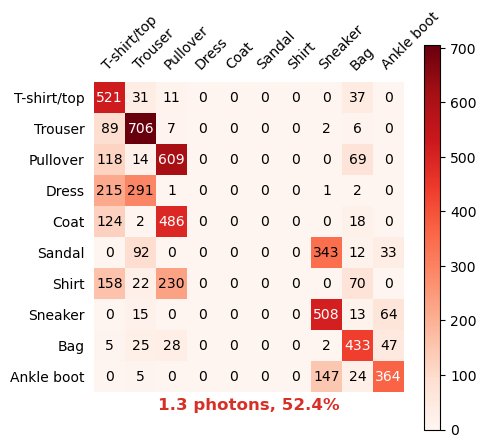

d_f = 4: 2.1 photons, 62.6%


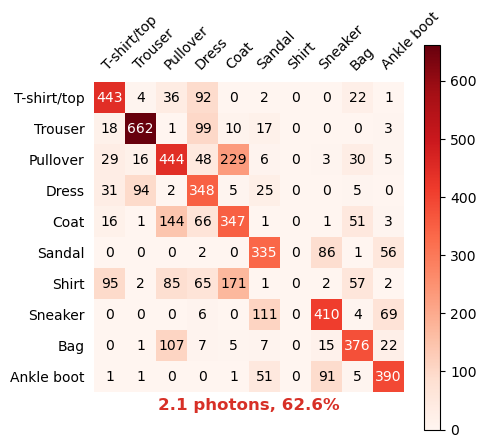

d_f = 6: 3.1 photons, 65.8%


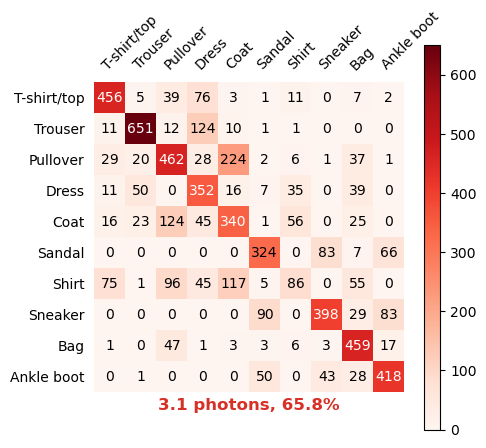

d_f = 10: 4.9 photons, 73.2%


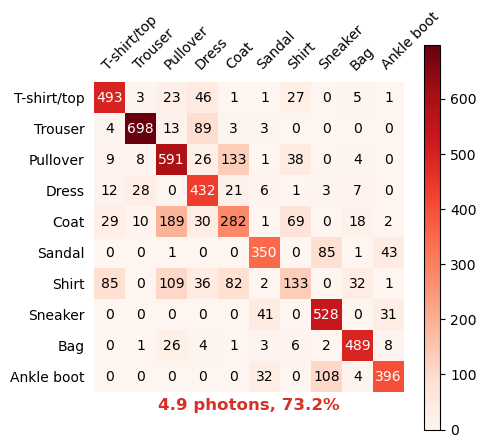

d_f = 16: 8.6 photons, 77.2%


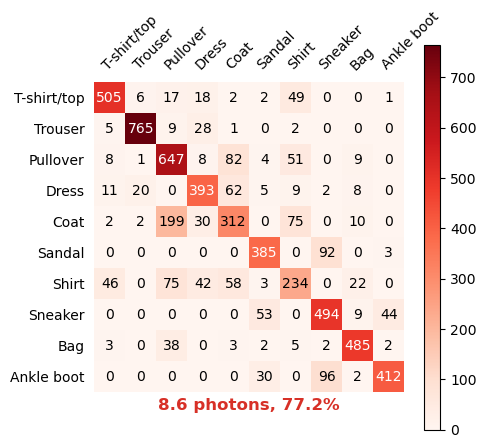

d_f = 24: 12.6 photons, 79.4%


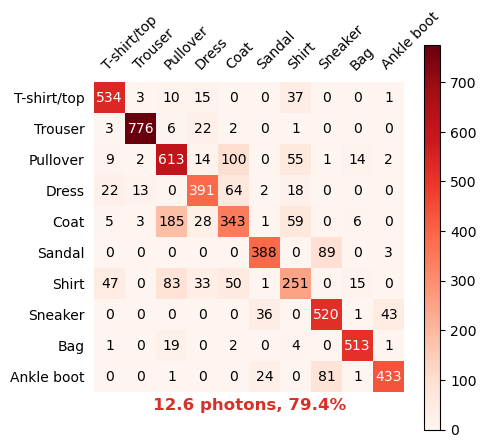

d_f = 32: 17.2 photons, 82.1%


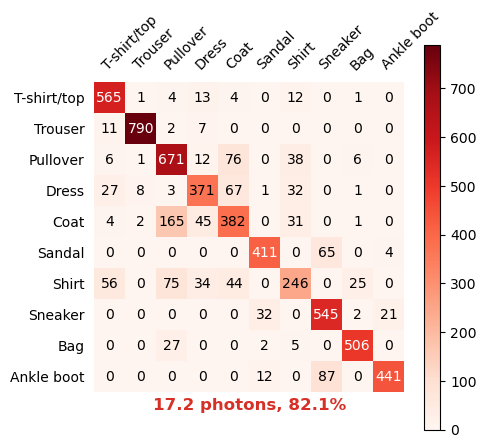

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

FASHIONMNIST_LABELS = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

def evaluate_acts(acts, model, images, labels, device='cpu'):
    """Evaluate model on given activations (same pattern as test_MNIST_clean)."""
    model.to(device)
    model.eval()

    with torch.no_grad():
        images, labels = images.to(device), labels.to(device)
        acts_t = torch.as_tensor(acts, dtype=torch.float32, device=device)
        outputs = model.acts_out(acts_t)
        _, predicted = torch.max(outputs, dim=1)

        correct = (predicted == labels).sum().item()
        total = labels.size(0)

    accuracy = 100.0 * correct / total
    conf_mat = confusion_matrix(labels.cpu().numpy(), predicted.cpu().numpy())

    return accuracy, conf_mat

def plot_confusion_matrix(cm, labels, title, save_path=None):
    """Plot and optionally save confusion matrix."""
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap='Reds')
    ax.figure.colorbar(im, ax=ax, aspect=23)

    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    
    ax.xaxis.set_label_position('top') 
    ax.xaxis.tick_top()
    plt.setp(ax.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")

    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_aspect('equal')
    ax.tick_params(top=False, bottom=False, left=False, right=False)
    ax.spines[:].set_visible(False)

    ax.xaxis.set_label_position('bottom')

    ax.set_xlabel(title, fontsize=12, fontweight='bold', color='#d73027ff')

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')

    if save_path:
        plt.savefig(save_path)
    plt.show()

    return fig

K = 1
conf_mats = {}
mean_acc = {}

for N in exp_Ns:
    model = exp_models[N]
    det_actv = torch.from_numpy(
        exp_actvs[N].reshape(K, -1, test_batch_size, N, order='F').mean(axis=0)
    ).type(torch.float32)
    n_T = det_actv.shape[0]
    acc, conf_mat = evaluate_acts(det_actv[0].numpy(), model, test_input_i, test_labels_i, device=device)
    for i in range(n_T - 1):
        aa, cc = evaluate_acts(det_actv[i + 1].numpy(), model, test_input_i, test_labels_i, device=device)
        acc += aa
        conf_mat += cc
    acc = acc / n_T

    conf_mats[N] = np.asarray(conf_mat, dtype=np.int64)
    mean_acc[N] = acc

    N_det = det_actv.mean().item() * N
    title = f'{N_det:.1f} photons, {acc:.1f}%'

    print(f'd_f = {N}: {title}')
    plot_confusion_matrix(conf_mat, FASHIONMNIST_LABELS, title,
                          save_path=plotPath / f'fashion_exp_conf_mat_df{N}_{acc:.2f}.png')

ordered_N = sorted(conf_mats.keys())
save_kw = {f'cm_{N}': conf_mats[N] for N in ordered_N}
save_kw['Ns'] = np.array(ordered_N, dtype=np.int64)
save_kw['K'] = np.array(K, dtype=np.int32)
save_kw['mean_acc_percent'] = np.array([mean_acc[N] for N in ordered_N], dtype=np.float64)
save_kw['labels'] = np.array(FASHIONMNIST_LABELS)
np.savez_compressed(savePath / 'fashion_exp_conf_mats.npz', **save_kw)

# Simulated digital-twin

In [9]:
import pandas as pd
import numpy as np
import torch

# create a DataFrame for the results
sim_results_df = pd.DataFrame(columns=['N', 'K', 'mean_accuracy', 'std_dev'])
torch.manual_seed(0)

nr = 100
Ks = np.r_[1,2,3,5]
acc_arr = np.zeros((len(Ks),nr))

temp_results = []

for N in exp_Ns:
    for Ki, K in enumerate(Ks):
        for j in range(nr):
            output = exp_models[N](test_input_i,n_rep=K)
            pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
            correct = pred.eq(test_labels_i.data.view_as(pred)).cpu().sum()
            acc_arr[Ki,j] = correct / test_batch_size

        mean_acc = 100. * acc_arr[Ki].mean()
        std_dev = 100. * acc_arr[Ki].std()

        # append the results to your DataFrame
        temp_results.append({'N': int(N), 'K': int(K), 'mean_accuracy': mean_acc, 'std_dev': std_dev})

sim_results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)


# Pivot the DataFrame so that 'K' are columns and 'N' are rows with 'mean_accuracy' and 'std_dev' together in the same cell
sim_results_df['results'] = sim_results_df.apply(lambda row: \
                            f"{np.round(row['mean_accuracy'],2):.2f} ± {np.round(row['std_dev'],2):.2f}%", axis=1)
sim_results_df_print = format_pivot(sim_results_df.pivot(index='N', columns='K', values='results'))

sim_results_df_print

,K = 1,K = 2,K = 3,K = 5
N = 3,54.46 ± 1.31%,55.20 ± 1.67%,55.88 ± 1.35%,56.68 ± 1.44%
N = 4,65.11 ± 2.07%,66.26 ± 1.90%,67.20 ± 1.55%,68.38 ± 1.59%
N = 6,68.37 ± 2.06%,70.15 ± 1.84%,71.33 ± 1.50%,71.29 ± 1.32%
N = 10,74.31 ± 1.84%,77.55 ± 1.32%,77.53 ± 1.32%,78.48 ± 1.16%
N = 16,78.30 ± 1.96%,81.42 ± 1.48%,81.85 ± 1.36%,82.34 ± 1.32%
N = 24,80.35 ± 1.78%,81.98 ± 1.39%,82.22 ± 1.26%,82.35 ± 1.16%
N = 32,83.13 ± 1.48%,84.39 ± 1.48%,85.02 ± 1.15%,85.34 ± 1.05%


In [10]:
sim_results_df.to_pickle(savePath / 'fashion_active_sim.npy')

## Comparison plot

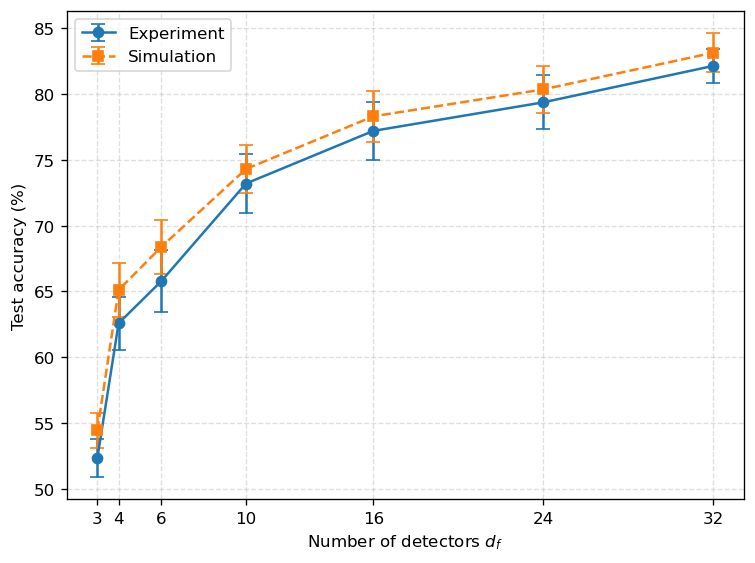

In [11]:
# Plot N vs accuracy with errorbars (uses existing variables in the notebook)
import matplotlib.pyplot as plt

k_val = 1

fig, ax = plt.subplots(dpi=120)

exp_sel = exp_results_df[exp_results_df['K'] == k_val].sort_values('N')
sim_sel = sim_results_df[sim_results_df['K'] == k_val].sort_values('N')

ax.errorbar(exp_sel['N'], exp_sel['mean_accuracy'], yerr=exp_sel['std_dev'],
            fmt='o-', label=f'Experiment', capsize=4)
ax.errorbar(sim_sel['N'], sim_sel['mean_accuracy'], yerr=sim_sel['std_dev'],
            fmt='s--', label=f'Simulation', capsize=4)

ax.set_xlabel(r'Number of detectors $d_f$')
ax.set_ylabel('Test accuracy (%)')
ax.set_xticks(sorted(exp_sel['N'].unique()))
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()